# Analyse: DQN vs. PPO (Poster-Grafiken & Statistik)

Ausführlicher Vergleich mit Tabellen, Signifikanztests und Grafiken. Setzt voraus,
dass beide finalen Läufe fertig sind (`results/metrics/dqn.csv` & `ppo.csv`).

- **A** Zusammenfassungs-Tabelle (best & final Modell)
- **B** Vergleichs-Boxplot mit Einzel-Seeds
- **C** Sample-Effizienz (Steps bis ≥ 200)
- **D** Stabilität: bestes vs. finales Modell (catastrophic forgetting)
- **E** Signifikanztests (Welch + Mann-Whitney)
- **F** Reward-Verteilung des besten Seeds
- **G** Mittelwert über 10 Durchläufe + Zufalls-Baseline

> Hinweis: Einige Zellen laden gespeicherte Modelle und **bewerten neu** — das dauert
> ein paar Minuten. Grafiken landen in `results/analysis/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from IPython.display import Image, display

from lunarlander import config, stats, plots
from lunarlander.agents import load_agent, make_random_agent
from lunarlander.envs import make_env
from lunarlander.evaluate import evaluate

ALGOS = ["dqn", "ppo"]
OUT = config.RESULTS_DIR / "analysis"
OUT.mkdir(parents=True, exist_ok=True)

# beste-Modell-Renditen je Seed aus den finalen CSVs
best = {a: pd.read_csv(config.METRICS_DIR / f"{a}.csv")["mean_reward"].values for a in ALGOS}
for a in ALGOS:
    print(f"[{a.upper()}] best je Seed: {np.round(best[a], 1).tolist()}")

[DQN] best je Seed: [227.2, 227.4, 250.0, 233.5, 242.4]
[PPO] best je Seed: [254.9, 222.4, 221.9, 239.5, 261.6]


## A. Zusammenfassungs-Tabelle
Kennzahlen je Algorithmus für **bestes** und **finales** Modell. (Die finalen Werte
werden hier neu berechnet — dauert ein paar Minuten.)

In [2]:
# Finale-Modell-Renditen neu berechnen (lädt final_model je Seed)
final = {}
for a in ALGOS:
    vals = []
    for s in config.SEEDS:
        m = load_agent(a, config.MODELS_DIR / f"{a}_seed{s}" / "final_model")
        vals.append(evaluate(m, seed=10_000 + s, n_episodes=config.N_EVAL_EPISODES).mean())
    final[a] = np.array(vals)

rows = []
for a in ALGOS:
    for which, data in (("best", best[a]), ("final", final[a])):
        d = stats.describe(data, threshold=config.SOLVED_THRESHOLD)
        rows.append({
            "Algo": a.upper(), "Modell": which,
            "Mean": round(d["mean"], 1), "Std": round(d["std"], 1),
            "95% CI": f"[{d['ci_low']:.0f}, {d['ci_high']:.0f}]",
            "Min": round(d["min"], 1), "Max": round(d["max"], 1),
            "solved": f"{d['n_solved']}/{len(data)}",
        })
summary = pd.DataFrame(rows)
summary

objc[32880]: Class SDL_RumbleMotor is implemented in both /Users/fabian/dev/dhbw/RL_EU4DUAL/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x124298d40) and /Users/fabian/dev/dhbw/RL_EU4DUAL/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x128cb49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[32880]: Class SDL_RumbleContext is implemented in both /Users/fabian/dev/dhbw/RL_EU4DUAL/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x124298d90) and /Users/fabian/dev/dhbw/RL_EU4DUAL/.venv/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x128cb4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[32880]: Class SDLApplication is implemented in both /Users/fabian/dev/dhbw/RL_EU4DUAL/.venv/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x124298890) and 

,Algo,Modell,Mean,Std,95% CI,Min,Max,solved
0,DQN,best,236.1,9.9,"[224, 248]",227.2,250.0,5/5
1,DQN,final,152.5,65.0,"[72, 233]",60.7,229.5,1/5
2,PPO,best,240.1,18.2,"[217, 263]",221.9,261.6,5/5
3,PPO,final,218.6,39.4,"[170, 268]",160.3,258.7,4/5


## B. Vergleichs-Boxplot mit Einzel-Seeds
Bei n=5 ehrlicher: die tatsächlichen 5 Seed-Werte über dem Box.

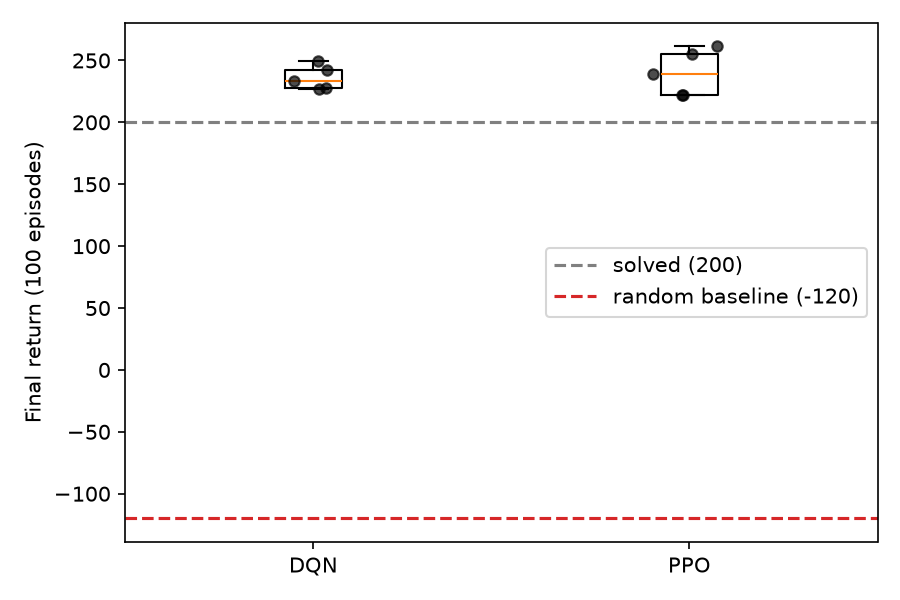

In [3]:
png = plots.comparison_plot(best, OUT / "comparison_points.png",
                            baseline=-120, show_points=True)
display(Image(filename=str(png)))

## C. Sample-Effizienz
Nach wie vielen Steps erreicht die **mittlere** Eval-Rendite (über Seeds) zum ersten Mal ≥ 200?

Steps bis mittlere Rendite ≥ 200: {'dqn': 220000, 'ppo': 180000}


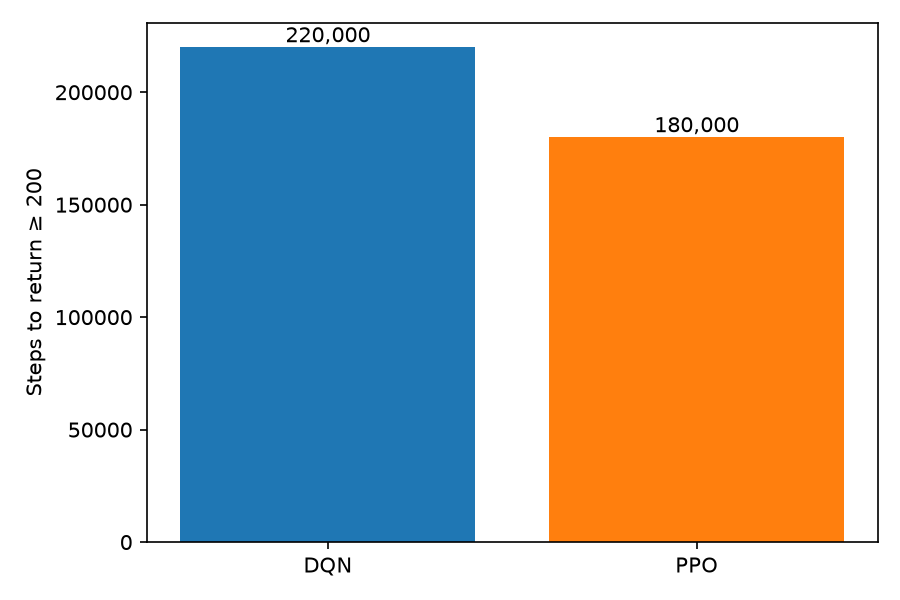

In [4]:
steps = {}
for a in ALGOS:
    per_seed, ts = [], None
    for s in config.SEEDS:
        d = np.load(config.MODELS_DIR / f"{a}_seed{s}" / "evaluations.npz")
        ts = d["timesteps"]
        per_seed.append(d["results"].mean(axis=1))
    mean_curve = np.vstack(per_seed).mean(axis=0)
    steps[a] = stats.steps_to_threshold(ts, mean_curve, threshold=config.SOLVED_THRESHOLD)

print("Steps bis mittlere Rendite ≥ 200:", steps)
png = plots.efficiency_plot(steps, OUT / "efficiency.png")
display(Image(filename=str(png)))

## D. Stabilität: bestes vs. finales Modell
Großer Abstand = starkes *catastrophic forgetting* am Trainingsende.

best : {'dqn': 236.1, 'ppo': 240.1}
final: {'dqn': 152.5, 'ppo': 218.6}


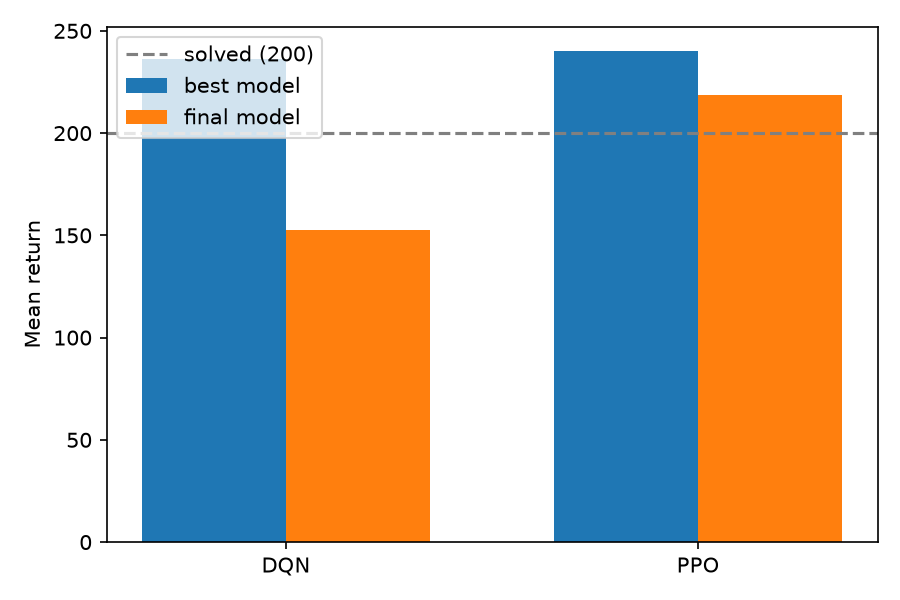

In [5]:
best_mean = {a: float(best[a].mean()) for a in ALGOS}
final_mean = {a: float(final[a].mean()) for a in ALGOS}
print("best :", {a: round(v, 1) for a, v in best_mean.items()})
print("final:", {a: round(v, 1) for a, v in final_mean.items()})
png = plots.gap_plot(best_mean, final_mean, OUT / "gap.png")
display(Image(filename=str(png)))

## E. Signifikanztests (bestes Modell)
Welch-t-Test (parametrisch) **und** Mann-Whitney-U (nicht-parametrisch, robust bei n=5).

In [6]:
res = stats.summarize(best["dqn"], best["ppo"], "dqn", "ppo")
_, p_mw = stats.mann_whitney(best["dqn"], best["ppo"])

print("Welch t-Test (DQN vs. PPO):")
print(f"  p            = {res['p_value']:.4f}")
print(f"  Cohen's d    = {res['cohens_d']:.2f}")
print(f"  CI(DQN)      = ({res['ci_dqn'][1]:.1f}, {res['ci_dqn'][2]:.1f})")
print(f"  CI(PPO)      = ({res['ci_ppo'][1]:.1f}, {res['ci_ppo'][2]:.1f})")
print(f"  CI(DQN−PPO)   = ({res['ci_diff'][1]:.1f}, {res['ci_diff'][2]:.1f})")
print(f"\nMann-Whitney-U (robust): p = {p_mw:.4f}")
print("\nHinweis: schließt CI(DQN−PPO) die 0 ein und ist p > 0.05,")
print("ist der Unterschied statistisch nicht signifikant (beide lösen die Aufgabe).")

Welch t-Test (DQN vs. PPO):
  p            = 0.6842
  Cohen's d    = -0.27
  CI(DQN)      = (223.8, 248.4)
  CI(PPO)      = (217.5, 262.7)
  CI(DQN−PPO)   = (-26.5, 18.6)

Mann-Whitney-U (robust): p = 1.0000

Hinweis: schließt CI(DQN−PPO) die 0 ein und ist p > 0.05,
ist der Unterschied statistisch nicht signifikant (beide lösen die Aufgabe).


## F. Reward-Verteilung des besten Seeds
Histogramm der 100 Eval-Episoden — zeigt, wie *konsistent* die beste Policy landet.

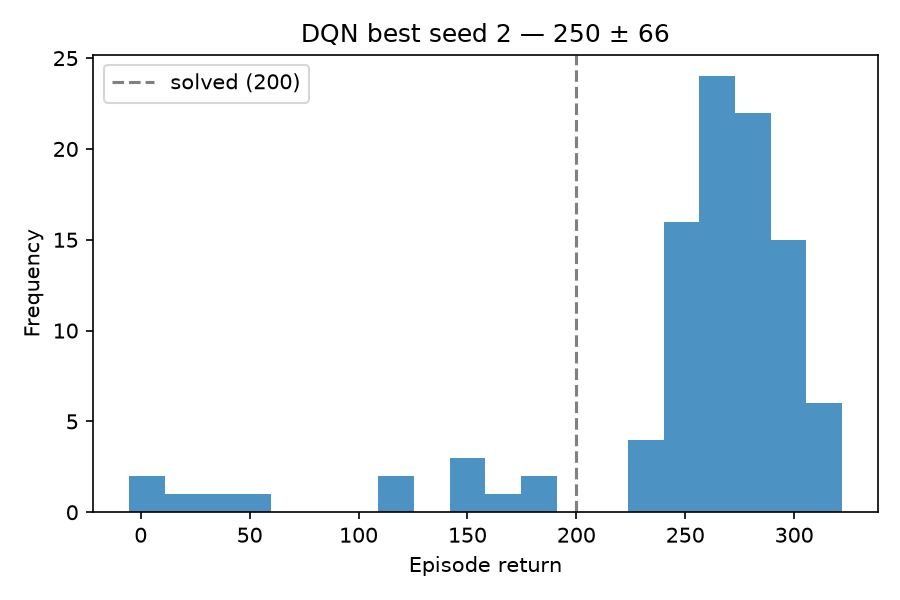

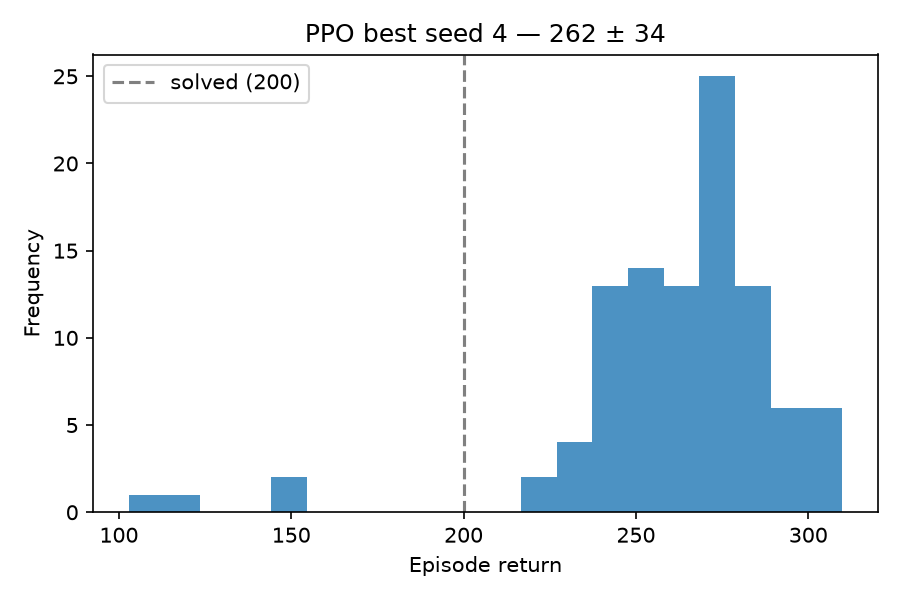

In [7]:
for a in ALGOS:
    seed = int(config.SEEDS[int(np.argmax(best[a]))])
    m = load_agent(a, config.MODELS_DIR / f"{a}_seed{seed}" / "best_model")
    rewards = evaluate(m, seed=10_000 + seed, n_episodes=config.N_EVAL_EPISODES)
    png = plots.reward_histogram(
        rewards, OUT / f"hist_{a}.png",
        label=f"{a.upper()} best seed {seed} — {rewards.mean():.0f} ± {rewards.std():.0f}")
    display(Image(filename=str(png)))

## G. Mittelwert über 10 Durchläufe (bestes Modell) — mit Zufalls-Baseline
Die Poster-/Präsentationszahl: das jeweils **beste Modell** (bester Seed) wird über
`N_RUNS = 10` Episoden bewertet, ausgegeben als Mittelwert ± Std plus die 10 Einzelwerte —
als Balkengrafik und im Vergleich zu einer **Zufalls-Policy** auf denselben Episoden.

Die Zufalls-Baseline ist der Boden, den ein Algorithmus schlagen muss: sie beantwortet
„ist das Ergebnis gelernt oder nur die Umgebung?". Sie läuft über dasselbe `evaluate()`
wie DQN/PPO — nur dass die Policy gleichverteilt aus dem Aktionsraum zieht.

> Hinweis: 10 Episoden sind eine kleine Stichprobe → dieser Mittelwert schwankt stärker
> als die 100-Episoden-Zahl aus Abschnitt A/F. Für eine belastbarere Zahl `N_RUNS` erhöhen.

Mittelwert über 10 Durchläufe:

  DQN     (bester Seed 2 ):   219.1 ±  96.8
                              [295, 295, 266, 264, 38, 271, 20, 263, 244, 235]

  PPO     (bester Seed 4 ):   266.9 ±  12.6
                              [284, 259, 291, 252, 264, 268, 268, 266, 247, 272]

  RANDOM  (Baseline      ):  -196.0 ±  93.4
                              [-332, -109, -121, -76, -105, -227, -129, -323, -288, -250]

Abstand zum Zufall: DQN +415, PPO +463


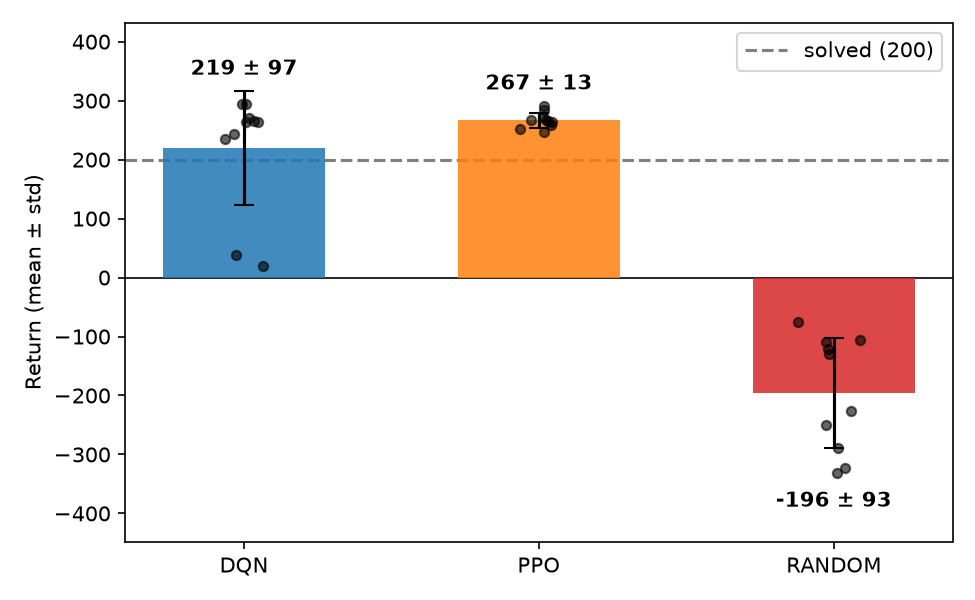

In [8]:
# Mittelwert über N Durchläufe (Episoden) mit dem jeweils besten Modell — fürs Poster
N_RUNS = 10
EVAL_SEED = 12_345   # fester Seed → reproduzierbar, und für alle derselbe

runs, beste_seeds = {}, {}
for a in ALGOS:
    beste_seeds[a] = int(config.SEEDS[int(np.argmax(best[a]))])
    m = load_agent(a, config.MODELS_DIR / f"{a}_seed{beste_seeds[a]}" / "best_model")
    runs[a] = evaluate(m, seed=EVAL_SEED, n_episodes=N_RUNS)

# Zufalls-Baseline auf denselben Start-Zuständen. Der Key ist das Balken-Label in der
# Grafik (englisch), und er muss ans Ende von `runs`: die Plot-Farben gehen nach
# Position, der letzte Balken wird rot.
env = make_env(seed=EVAL_SEED)
runs["random"] = evaluate(make_random_agent(env, seed=EVAL_SEED), seed=EVAL_SEED, n_episodes=N_RUNS)
env.close()

print(f"Mittelwert über {N_RUNS} Durchläufe:\n")
for label, r in runs.items():
    woher = f"bester Seed {beste_seeds[label]}" if label in beste_seeds else "Baseline"
    einzel = ", ".join(f"{x:.0f}" for x in r)
    print(f"  {label.upper():7s} ({woher:14s}): {r.mean():7.1f} ± {r.std():5.1f}")
    print(f"  {'':26s}  [{einzel}]\n")

print(f"Abstand zum Zufall: " + ", ".join(
    f"{a.upper()} +{runs[a].mean() - runs['random'].mean():.0f}" for a in ALGOS))

png = plots.mean_runs_plot(runs, OUT / "mean_runs.png")
display(Image(filename=str(png)))

## H. Suchraum-Erweiterung (PPO): Verbesserung bei gleichem Budget
Das Tuning zeigte, dass wichtige Parameter am **Rand** des Suchraums lagen
(`n_epochs`, `net_arch`, `n_steps` — siehe `docs/figures/range_widening_lesson`). Nach dem
**Erweitern des Suchraums** und erneutem Tuning verbessert sich PPO — hier fair bei
**gleichem 500k-Trainingsbudget** (Standard- vs. erweiterter Suchraum). Der Effekt kommt
also aus dem Suchraum, nicht aus mehr Rechenzeit.

Poster-Grafik (Englisch): `docs/figures/search_space_improvement.png`.

PPO standard search space (500k): 240.1 ± 18.2  (solved 5/5)
PPO extended search space (500k): 253.9 ± 22.0  (solved 5/5)
Improvement from widening the search space: +13.9


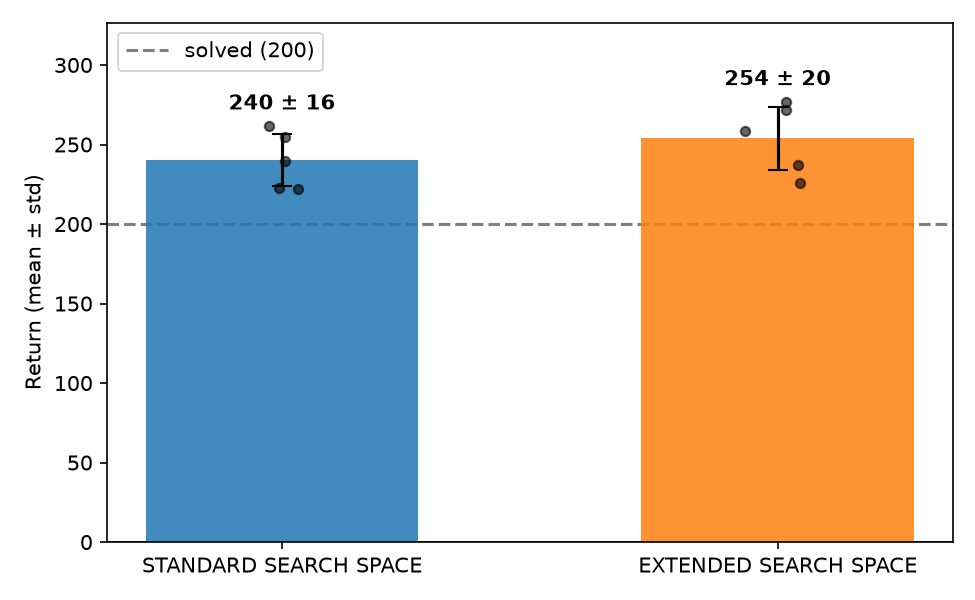

In [9]:
# H. Suchraum-Erweiterung: Standard vs. erweiterter Suchraum (gleiches 500k-Budget)
std = pd.read_csv(config.METRICS_DIR / "ppo.csv")["mean_reward"].values
ext_path = config.METRICS_DIR / "ppo_v2_500k.csv"
if ext_path.exists():
    ext = pd.read_csv(ext_path)["mean_reward"].values
    ds, de = stats.describe(std), stats.describe(ext)
    print(f"PPO standard search space (500k): {ds['mean']:.1f} ± {ds['std']:.1f}  (solved {ds['n_solved']}/5)")
    print(f"PPO extended search space (500k): {de['mean']:.1f} ± {de['std']:.1f}  (solved {de['n_solved']}/5)")
    print(f"Improvement from widening the search space: +{de['mean'] - ds['mean']:.1f}")
    png = plots.mean_runs_plot(
        {"standard search space": std, "extended search space": ext},
        OUT / "search_space_ppo.png")
    display(Image(filename=str(png)))
else:
    print("results/metrics/ppo_v2_500k.csv fehlt — erst den v2@500k-Lauf machen:")
    print("  uv run python -m scripts.run_final_eval --algo ppo --params '<v2 best_params>' --tag v2_500k")

## Interpretation fürs Poster
_(hier die Kernaussagen notieren, sobald die Zahlen oben stehen)_

- Endleistung DQN vs. PPO: …
- Sample-Effizienz: …
- Stabilität (best vs. final): …
- Signifikanz: …